<a href="https://colab.research.google.com/github/madhan07srmist-web/AI_ProblemSolving_RA2411026050005_RA2411026050042/blob/master/TF_IDF_Text_Similarity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Politics .txt to Politics .txt
Saving education .txt to education .txt
Saving Sports .txt to Sports .txt
Saving Technology.txt to Technology.txt


In [9]:
file_names = [
    "Technology.txt",
    "Sports .txt",
    "education .txt",
    "Politics .txt"
]

documents = []

for file in file_names:
    with open(file, "r", encoding="utf-8") as f:
        text = f.read()
        documents.append(text)

print("All 4 text files loaded successfully!")

All 4 text files loaded successfully!


In [10]:
for i, document in enumerate(documents):
    print("\n" + "=" * 60)
    print("FILE:", file_names[i])
    print("=" * 60)
    print(document)


FILE: Technology.txt
﻿Artificial intelligence is becoming an important part of modern technology.
Artificial intelligence systems can analyze large amounts of data and
identify useful patterns. Machine learning is a branch of artificial
intelligence that allows computers to learn from previous data and
experience.


Technology companies are developing intelligent software for education,
healthcare, banking and transportation. Artificial intelligence is used
in recommendation systems, chatbots, image recognition and language
processing. Cloud computing allows users to access computing resources
and software through the internet.


Software developers use programming languages such as Python, Java and
C++ to create applications. Data science and machine learning are
important areas of modern computer science. The development of artificial
intelligence is creating new opportunities for businesses and students.


Cybersecurity is also important because digital systems must protect
informa

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    stop_words="english",
    lowercase=True
)

# Apply TF-IDF to all 4 documents
tfidf_matrix = vectorizer.fit_transform(documents)

# Display matrix information
print("TF-IDF Algorithm Applied Successfully!")
print("Number of documents:", tfidf_matrix.shape[0])
print("Number of unique words:", tfidf_matrix.shape[1])
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Algorithm Applied Successfully!
Number of documents: 4
Number of unique words: 229
TF-IDF Matrix Shape: (4, 229)


In [12]:
import pandas as pd

# Get all words identified by TF-IDF
feature_names = vectorizer.get_feature_names_out()

# Convert the TF-IDF matrix into a table
tfidf_dataframe = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=file_names
)

# Display the TF-IDF matrix
tfidf_dataframe

,abilities,academic,access,accountability,activities,activity,administration,allow,allows,amounts,...,use,used,useful,users,values,voters,watched,way,work,world
Technology.txt,0.000000,0.000000,0.124282,0.000000,0.000000,0.000000,0.000000,0.000000,0.157636,0.078818,...,0.078818,0.062141,0.062141,0.078818,0.000000,0.000000,0.000000,0.078818,0.078818,0.000000
Sports .txt,0.000000,0.000000,0.000000,0.000000,0.082535,0.082535,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.082535,0.000000,0.082535,0.000000,0.000000,0.082535
education .txt,0.093782,0.093782,0.073939,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.073939,0.073939,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Politics .txt,0.000000,0.000000,0.000000,0.099849,0.000000,0.000000,0.199699,0.099849,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.099849,0.000000,0.000000,0.000000,0.000000


In [13]:
# Find the Top 10 important words in each document

for i, file in enumerate(file_names):

    # Get TF-IDF scores for the current document
    document_scores = tfidf_matrix[i].toarray()[0]

    # Get indices of the Top 10 highest scores
    top_indices = document_scores.argsort()[-10:][::-1]

    print("\n" + "=" * 50)
    print("Top 10 Important Words in:", file)
    print("=" * 50)

    # Display the words and their TF-IDF scores
    for index in top_indices:
        print(
            feature_names[index],
            ":",
            round(document_scores[index], 4)
        )


Top 10 Important Words in: Technology.txt
intelligence : 0.3941
artificial : 0.3941
data : 0.2365
software : 0.2365
systems : 0.2365
technology : 0.1864
machine : 0.1576
allows : 0.1576
computing : 0.1576
modern : 0.1576

Top 10 Important Words in: Sports .txt
sports : 0.4127
physical : 0.3301
improve : 0.3301
players : 0.2476
teamwork : 0.1651
popular : 0.1651
fitness : 0.1651
international : 0.1651
athletes : 0.1651
discipline : 0.1651

Top 10 Important Words in: education .txt
learning : 0.3697
students : 0.3592
education : 0.2993
subjects : 0.1876
society : 0.1876
knowledge : 0.1876
help : 0.1479
skills : 0.1479
develop : 0.1479
technology : 0.1479

Top 10 Important Words in: Politics .txt
public : 0.2995
citizens : 0.2995
policies : 0.1997
requires : 0.1997
political : 0.1997
government : 0.1997
administration : 0.1997
elections : 0.1997
national : 0.1997
development : 0.1912


In [14]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate similarity between all documents
similarity_matrix = cosine_similarity(tfidf_matrix)

# Convert similarity matrix into a table
similarity_dataframe = pd.DataFrame(
    similarity_matrix,
    index=file_names,
    columns=file_names
)

# Display the similarity table
similarity_dataframe

,Technology.txt,Sports .txt,education .txt,Politics .txt
Technology.txt,1.000000,0.015930,0.176864,0.043566
Sports .txt,0.015930,1.000000,0.059374,0.025937
education .txt,0.176864,0.059374,1.000000,0.067818
Politics .txt,0.043566,0.025937,0.067818,1.000000


In [15]:
max_similarity = 0
most_similar_pair = ()

# Compare every file with every other file
for i in range(len(file_names)):
    for j in range(i + 1, len(file_names)):

        score = similarity_matrix[i][j]

        print(
            file_names[i],
            "and",
            file_names[j],
            "=",
            round(score, 4)
        )

        # Check if this is the highest similarity
        if score > max_similarity:
            max_similarity = score
            most_similar_pair = (
                file_names[i],
                file_names[j]
            )

print("\n" + "=" * 50)
print("MOST SIMILAR DOCUMENTS")
print("=" * 50)

print("File 1:", most_similar_pair[0])
print("File 2:", most_similar_pair[1])
print("Similarity Score:", round(max_similarity, 4))

Technology.txt and Sports .txt = 0.0159
Technology.txt and education .txt = 0.1769
Technology.txt and Politics .txt = 0.0436
Sports .txt and education .txt = 0.0594
Sports .txt and Politics .txt = 0.0259
education .txt and Politics .txt = 0.0678

MOST SIMILAR DOCUMENTS
File 1: Technology.txt
File 2: education .txt
Similarity Score: 0.1769


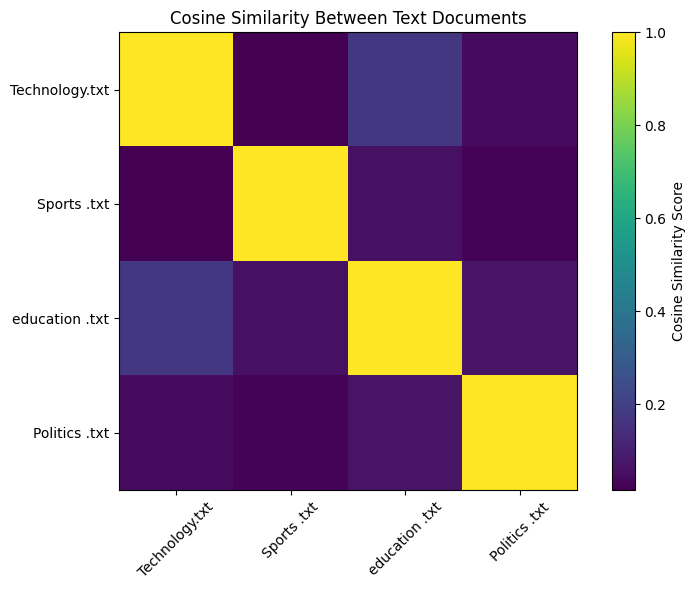

In [16]:
import matplotlib.pyplot as plt

# Create the similarity chart
plt.figure(figsize=(8, 6))

plt.imshow(similarity_matrix)

# Add similarity value scale
plt.colorbar(label="Cosine Similarity Score")

# Add file names
plt.xticks(
    range(len(file_names)),
    file_names,
    rotation=45
)

plt.yticks(
    range(len(file_names)),
    file_names
)

# Add title
plt.title("Cosine Similarity Between Text Documents")

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()